# 04 — Dimensionality Reduction

Reduce high-dimensional embeddings for clustering and visualization using PCA and UMAP.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

processed_dir = project_root / "data" / "processed"

df = pd.read_csv(processed_dir / "arxiv_clean.csv")
tfidf_matrix = sparse.load_npz(processed_dir / "tfidf_vectors.npz")
minilm_emb = np.load(processed_dir / "minilm_embeddings.npy")
kalm_emb = np.load(processed_dir / "kalm_embeddings.npy")

print(f"Papers: {len(df):,}")
print(f"TF-IDF: {tfidf_matrix.shape}")
print(f"MiniLM: {minilm_emb.shape}")
print(f"KaLM: {kalm_emb.shape}")

Papers: 181,294
TF-IDF: (181294, 27401)
MiniLM: (181294, 384)
KaLM: (181294, 896)


## SVD on TF-IDF

  TF-IDF is a sparse matrix with 27k dimensions — too large for UMAP directly. TruncatedSVD reduces it to 500
  dense dimensions first. We use TruncatedSVD instead of PCA because PCA would need to center the data,
  converting the sparse matrix to dense (~40GB in RAM).

   MiniLM (384d) and KaLM (896d) are already dense and compact, so they go directly into UMAP.

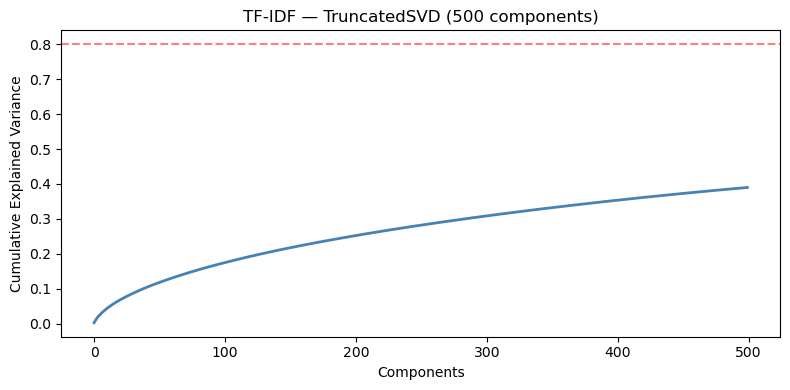

In [3]:
from src.features import reduce_svd

tfidf_svd, svd_model = reduce_svd(tfidf_matrix, n_components=500)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    np.cumsum(svd_model.explained_variance_ratio_),
    color="steelblue",
    linewidth=2,
)
ax.set_xlabel("Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("TF-IDF — TruncatedSVD (500 components)")
ax.axhline(y=0.8, color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## UMAP 20d — Baseline for Clustering

  UMAP reduces to 20 dimensions for clustering. Using n_neighbors=15, min_dist=0.0.

In [4]:
from src.features import reduce_umap

print("UMAP 20d on TF-IDF...")
tfidf_umap20 = reduce_umap(tfidf_svd, n_components=20)

print("UMAP 20d on MiniLM...")
minilm_umap20 = reduce_umap(minilm_emb, n_components=20)

print("UMAP 20d on KaLM...")
kalm_umap20 = reduce_umap(kalm_emb, n_components=20)

UMAP 20d on TF-IDF...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 20d on MiniLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 20d on KaLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## UMAP Hyperparameter Experiment

  Testing whether different UMAP settings improve clustering quality. Two experiments on KaLM only (our best
  embedding):

  1. **40d vs 20d** — does preserving more dimensions help?
  2. **n_neighbors=30 vs 15** — does broader neighborhood structure help with 181k papers?

In [6]:
print("UMAP 40d on KaLM...")
kalm_umap40 = reduce_umap(kalm_emb, n_components=40)

print("\nUMAP 20d with n_neighbors=30 on KaLM...")
kalm_umap20_n30 = reduce_umap(kalm_emb, n_components=20, n_neighbors=30)

UMAP 40d on KaLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



UMAP 20d with n_neighbors=30 on KaLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [7]:
import hdbscan
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score

experiments = {
    "20d, n=15": kalm_umap20,
    "40d, n=15": kalm_umap40,
    "20d, n=30": kalm_umap20_n30,
}

results = []
for name, data in experiments.items():
    # HDBSCAN
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=1000,
        min_samples=10,
        metric="euclidean",
    )
    hdb_labels = clusterer.fit_predict(data)
    n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    noise_pct = (hdb_labels == -1).mean() * 100
    mask = hdb_labels != -1
    hdb_sil = silhouette_score(data[mask], hdb_labels[mask], sample_size=10000)
    hdb_db = davies_bouldin_score(data[mask], hdb_labels[mask])

    results.append(
        {
            "Setting": name,
            "Algorithm": "HDBSCAN",
            "Clusters": n_clusters,
            "Noise %": round(noise_pct, 1),
            "Silhouette": round(hdb_sil, 4),
            "Davies-Bouldin": round(hdb_db, 4),
        }
    )

    # K-Means
    km = KMeans(n_clusters=24, random_state=42, n_init=10)
    km_labels = km.fit_predict(data)
    km_sil = silhouette_score(data, km_labels, sample_size=10000)
    km_db = davies_bouldin_score(data, km_labels)

    results.append(
        {
            "Setting": name,
            "Algorithm": "K-Means",
            "Clusters": 24,
            "Noise %": 0.0,
            "Silhouette": round(km_sil, 4),
            "Davies-Bouldin": round(km_db, 4),
        }
    )

comparison = pd.DataFrame(results)
print(comparison.to_string(index=False))

  Setting Algorithm  Clusters  Noise %  Silhouette  Davies-Bouldin
20d, n=15   HDBSCAN        41     36.9      0.4997          0.7358
20d, n=15   K-Means        24      0.0      0.3978          0.9448
40d, n=15   HDBSCAN        43     35.5      0.5074          0.7343
40d, n=15   K-Means        24      0.0      0.3925          0.9101
20d, n=30   HDBSCAN        44     36.8      0.4816          0.7651
20d, n=30   K-Means        24      0.0      0.3719          0.9860


## Decision

  **Winner: 40d with n_neighbors=15.** Highest HDBSCAN silhouette (0.5074), lowest Davies-Bouldin (0.7343), and
  slightly less noise (35.5% vs 36.9%). The extra dimensions preserve more structure for density-based
  clustering.

  n_neighbors=30 performed worst — the default local neighborhood (n=15) already captures cluster structure well
  at this dataset size.


In [9]:
print("UMAP 40d on TF-IDF...")
tfidf_umap40 = reduce_umap(tfidf_svd, n_components=40)

print("UMAP 40d on MiniLM...")
minilm_umap40 = reduce_umap(minilm_emb, n_components=40)

UMAP 40d on TF-IDF...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 40d on MiniLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## UMAP 2d and 3d for Visualization

Low-dimensional projections for scatter plots. These are for visualization only, not clustering.

In [10]:
print("UMAP 2d on TF-IDF...")
tfidf_umap2 = reduce_umap(tfidf_svd, n_components=2, min_dist=0.1)

print("UMAP 2d on MiniLM...")
minilm_umap2 = reduce_umap(minilm_emb, n_components=2, min_dist=0.1)

print("UMAP 2d on KaLM...")
kalm_umap2 = reduce_umap(kalm_emb, n_components=2, min_dist=0.1)

print("\nUMAP 3d on TF-IDF...")
tfidf_umap3 = reduce_umap(tfidf_svd, n_components=3, min_dist=0.1)

print("UMAP 3d on MiniLM...")
minilm_umap3 = reduce_umap(minilm_emb, n_components=3, min_dist=0.1)

print("UMAP 3d on KaLM...")
kalm_umap3 = reduce_umap(kalm_emb, n_components=3, min_dist=0.1)

UMAP 2d on TF-IDF...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2d on MiniLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2d on KaLM...


...

/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 3d on MiniLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 3d on KaLM...


/home/dino/miniforge3/envs/arxiv-trends/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


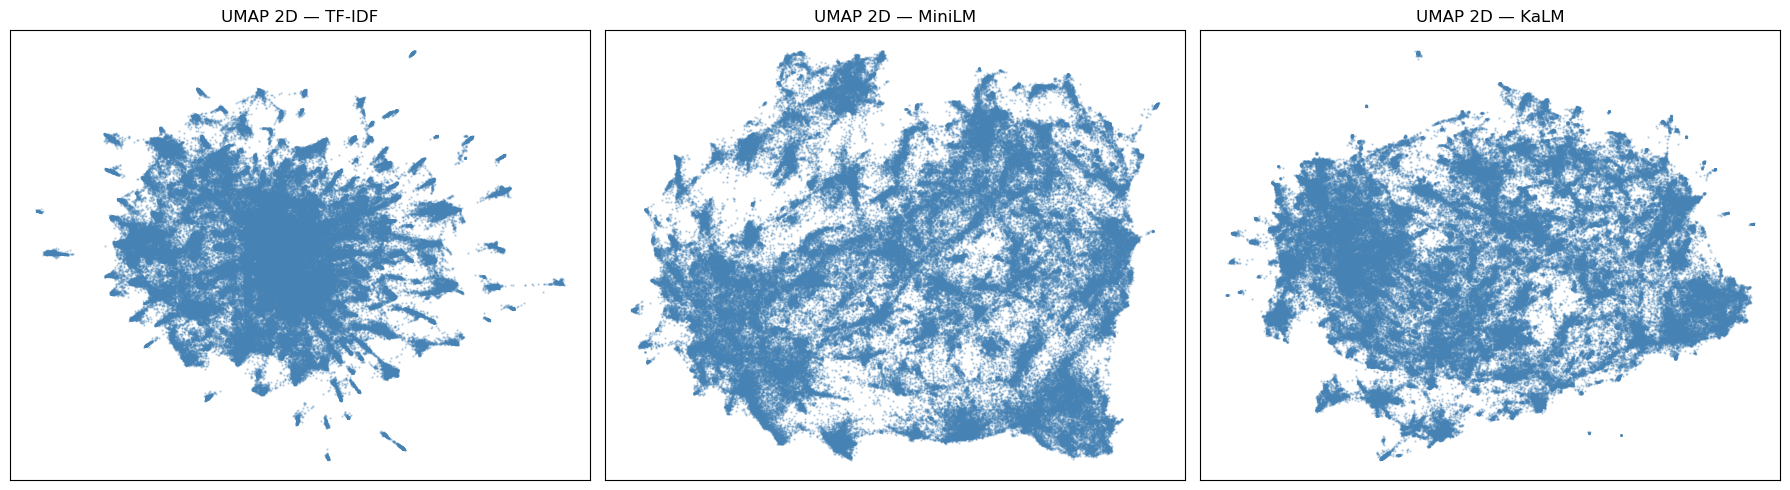

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, title in zip(
    axes,
    [tfidf_umap2, minilm_umap2, kalm_umap2],
    ["TF-IDF", "MiniLM", "KaLM"],
):
    ax.scatter(data[:, 0], data[:, 1], s=0.5, alpha=0.3, c="steelblue")
    ax.set_title(f"UMAP 2D — {title}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

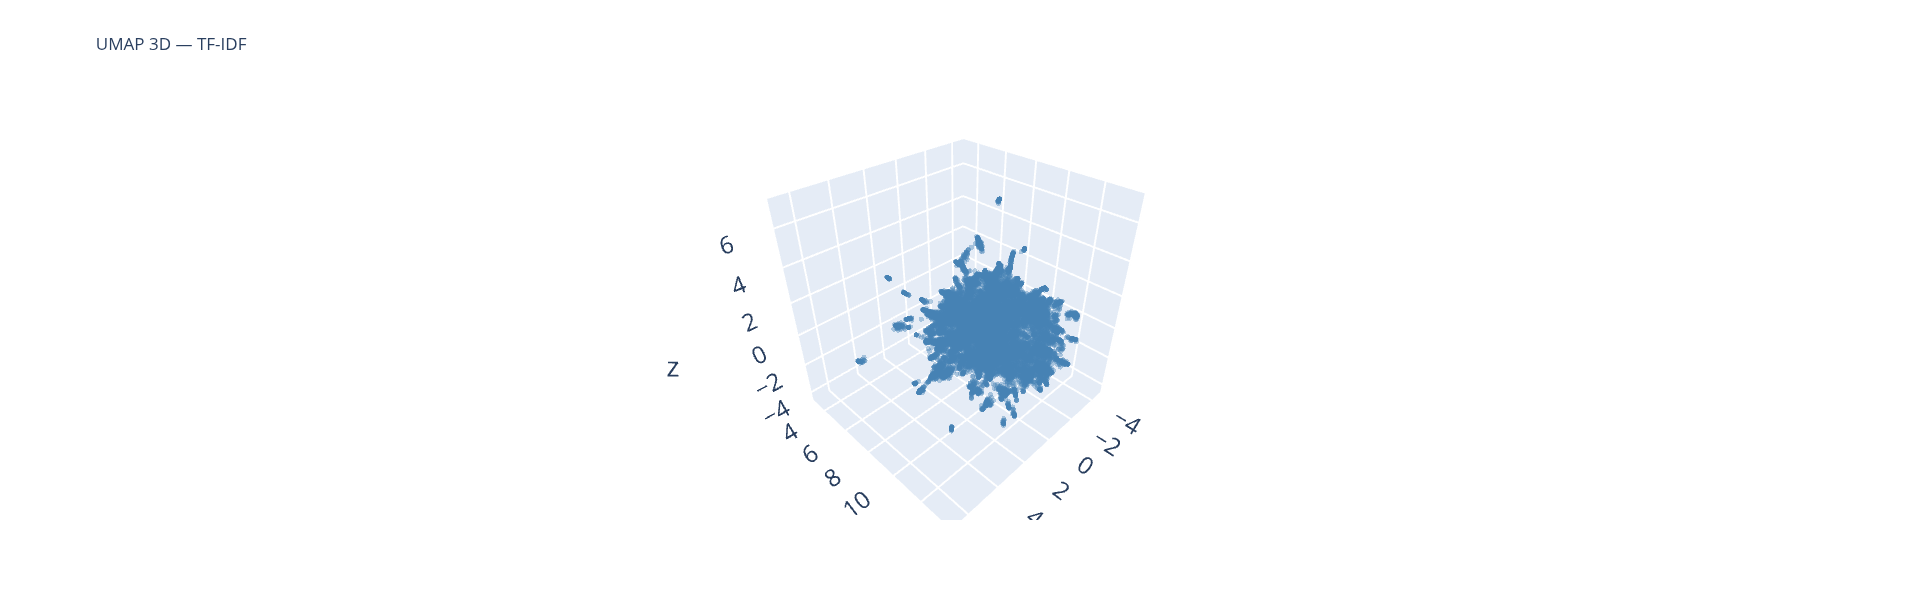

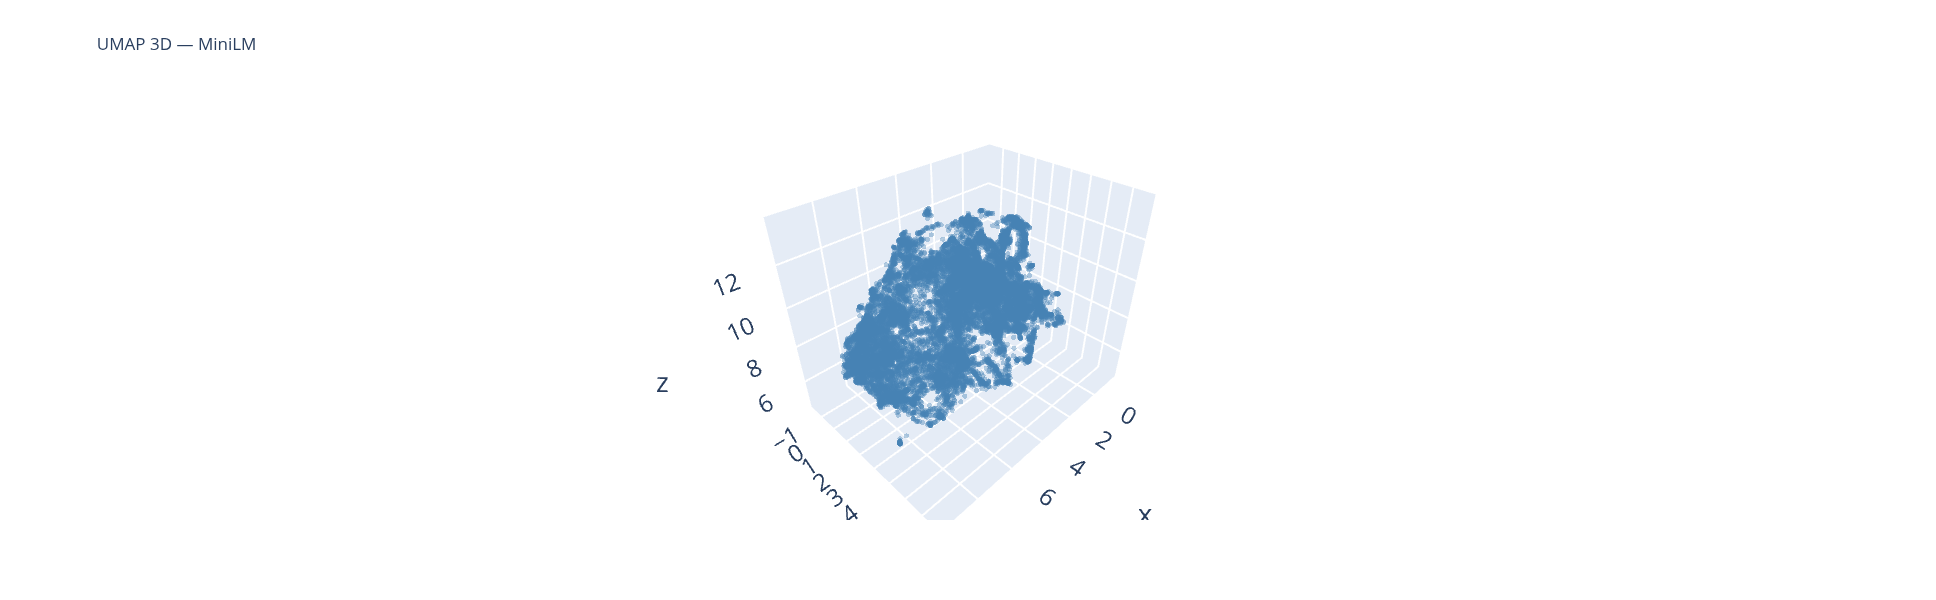

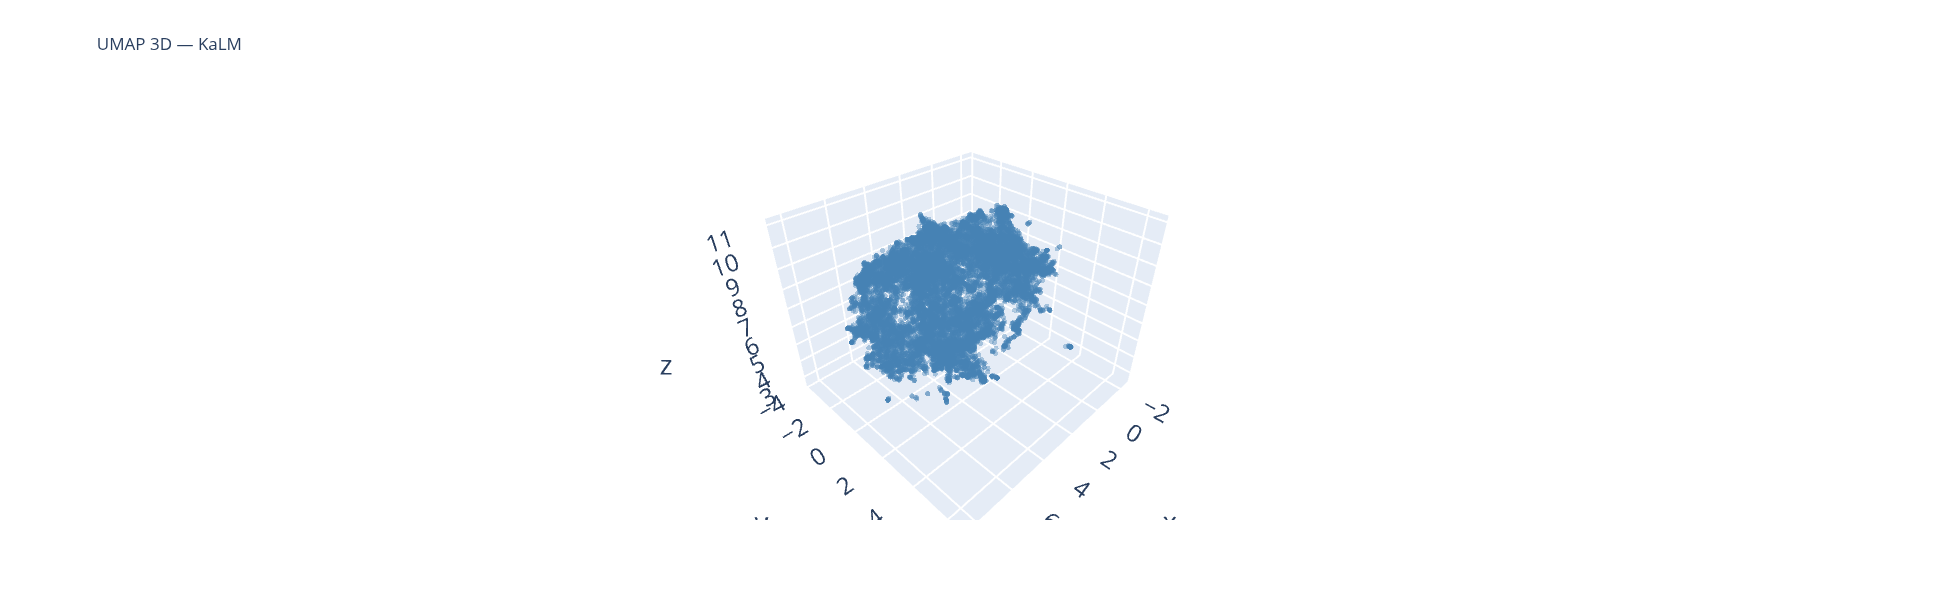

In [16]:
import plotly.graph_objects as go

sample_idx = np.random.RandomState(42).choice(len(df), size=20000, replace=False)

for data, title in [
    (tfidf_umap3, "TF-IDF"),
    (minilm_umap3, "MiniLM"),
    (kalm_umap3, "KaLM"),
]:
    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=data[sample_idx, 0],
                y=data[sample_idx, 1],
                z=data[sample_idx, 2],
                mode="markers",
                marker=dict(size=1.5, opacity=0.4, color="steelblue"),
            )
        ]
    )
    fig.update_layout(title=f"UMAP 3D — {title}", width=800, height=600)
    fig.show()

In [17]:
# 40d for clustering (winning setting from experiment)
np.save(processed_dir / "tfidf_umap_cluster.npy", tfidf_umap40)
np.save(processed_dir / "minilm_umap_cluster.npy", minilm_umap40)
np.save(processed_dir / "kalm_umap_cluster.npy", kalm_umap40)

# 2d for scatter plots
np.save(processed_dir / "tfidf_umap2.npy", tfidf_umap2)
np.save(processed_dir / "minilm_umap2.npy", minilm_umap2)
np.save(processed_dir / "kalm_umap2.npy", kalm_umap2)

# 3d for interactive plots
np.save(processed_dir / "tfidf_umap3.npy", tfidf_umap3)
np.save(processed_dir / "minilm_umap3.npy", minilm_umap3)
np.save(processed_dir / "kalm_umap3.npy", kalm_umap3)

## Summary

  **SVD:** TF-IDF 27,401d → 500d (39% variance retained)

  **UMAP experiment (KaLM only):**

  | Setting | Algorithm | Clusters | Noise % | Silhouette | Davies-Bouldin |
  |---------|-----------|----------|---------|------------|----------------|
  | 20d, n=15 | HDBSCAN | 41 | 36.9 | 0.4997 | 0.7358 |
  | **40d, n=15** | **HDBSCAN** | **43** | **35.5** | **0.5074** | **0.7343** |
  | 20d, n=30 | HDBSCAN | 44 | 36.8 | 0.4816 | 0.7651 |

  **Winner:** 40d, n_neighbors=15

  **Final UMAP outputs:**
  - 40d: for clustering (`*_umap_cluster.npy`)
  - 2d: for scatter plots (`*_umap2.npy`)
  - 3d: for interactive plots (`*_umap3.npy`)

  All saved to `data/processed/`.

  After everything runs, also update cell 6 (the baseline UMAP cell) to include the 40d runs so the notebook is
